In [30]:
"""
BSISO Detection: Intraseasonal OLR Anomaly Analysis
Compute 30-80 day band-pass filtered OLR anomalies
"""
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from geocat.comp.fourier_filters import fourier_band_pass
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geocat.viz as gv
import cmaps

## 2. Load and Process Data

In [31]:
def remove_anomalies(data):
    """Remove climatological annual cycle (day-of-year mean) from data."""
    climatology = data.groupby('time.dayofyear').mean('time')
    return data.groupby('time.dayofyear') - climatology


def extract_low_harmonics(data: xr.DataArray, 
                          n_harm: int = 3, 
                          dim: str = 'dayofyear') -> xr.DataArray:
    """
    Extract low-order harmonics using FFT.
    
    Parameters
    ----------
    data : xr.DataArray
        Input climatology data
    n_harm : int
        Number of harmonics to retain
    dim : str
        Dimension for FFT application
        
    Returns
    -------
    xr.DataArray
        Smoothed climatology
    """
    # Fourier transform
    z_fft = np.fft.rfft(data, axis=data.get_axis_num(dim))
    
    # Filter harmonics
    z_fft_filtered = z_fft.copy()
    if n_harm < z_fft.shape[data.get_axis_num(dim)]:
        z_fft_filtered[n_harm, :, :] *= 0.5
        z_fft_filtered[(n_harm+1):, :, :] = 0
    
    # Inverse FFT
    smoothed_data = np.fft.irfft(
        z_fft_filtered, 
        n=data.sizes[dim], 
        axis=data.get_axis_num(dim)
    ).real
    
    # Create output DataArray
    coords = {k: v for k, v in data.coords.items()}
    attrs = {
        "smoothing": f"FFT: {n_harm} harmonics retained",
        "units": data.attrs.get("units", ""),
        "long_name": f"Daily Climatology: {n_harm} harmonics retained",
    }
    
    return xr.DataArray(smoothed_data, coords=coords, dims=data.dims, attrs=attrs)



def geocat_fourier_bandpass(data, low_period=80, high_period=20):
    """
    Apply band-pass filter using geocat.comp.fourier_band_pass (frequency-domain).
    >>> olr_filtered_geocat = geocat_fourier_bandpass(
    ...     olr_anom_clean, low_period=80, high_period=20)
    """
    from geocat.comp.fourier_filters import fourier_band_pass

    fs               = 1.0              # daily sampling = 1 cycle/day
    cutoff_freq_low  = 1.0 / low_period   # e.g. 1/80 cycles/day
    cutoff_freq_high = 1.0 / high_period  # e.g. 1/20 cycles/day

    print(f"Applying geocat.comp.fourier_band_pass ({high_period}–{low_period} day)...")
    print(f"  cutoff_frequency_low  = 1/{low_period}  = {cutoff_freq_low:.5f} cycle/day")
    print(f"  cutoff_frequency_high = 1/{high_period} = {cutoff_freq_high:.5f} cycle/day")

    filtered = fourier_band_pass(
        data,
        frequency=fs,
        cutoff_frequency_low=cutoff_freq_low,
        cutoff_frequency_high=cutoff_freq_high,
        time_axis=0,
    )

    # Restore coordinates and attributes
    filtered = filtered.assign_coords(data.coords)
    filtered.attrs = data.attrs.copy()
    filtered.attrs['long_name'] = (
        f'{high_period}-{low_period} day fourier_band_pass (geocat)'
    )
    filtered.name = 'olr_anomaly_geocat_fourier'

    return filtered

In [32]:
# Load OLR data
ds = xr.open_dataset('./olr.day.mean.nc').sel(time=slice('1979-01-01', '2014-12-31')).chunk({'time': 5000})
olr = ds['olr']
olr

<xarray.DataArray 'olr' (time: 13149, lat: 73, lon: 144)> Size: 553MB
dask.array<xarray-olr, shape=(13149, 73, 144), dtype=float32, chunksize=(5000, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * time     (time) datetime64[ns] 105kB 1979-01-01 1979-01-02 ... 2014-12-31
Attributes:
    units:         W/m^2
    var_desc:      Outgoing Longwave Radiation
    precision:     2
    dataset:       NOAA Interpolated OLR
    level_desc:    Other
    statistic:     Mean
    parent_stat:   Individual Obs
    valid_range:   [  0. 500.]
    long_name:     Daily Mean OLR
    actual_range:  [ 64.75 344.5 ]

In [33]:
olr_low = extract_low_harmonics(olr, n_harm=3, dim='time')
olr_low

<xarray.DataArray (time: 13149, lat: 73, lon: 144)> Size: 553MB
array([[[181.63872 , 181.63872 , 181.63872 , ..., 181.63872 ,
         181.63872 , 181.63872 ],
        [182.73518 , 182.76503 , 182.78047 , ..., 182.19075 ,
         182.25308 , 182.38936 ],
        [184.70558 , 184.86319 , 184.89854 , ..., 184.12114 ,
         184.1818  , 184.32176 ],
        ...,
        [130.97826 , 130.54509 , 130.1073  , ..., 133.78218 ,
         133.37419 , 132.95692 ],
        [130.37248 , 130.18733 , 130.00127 , ..., 131.81352 ,
         131.63525 , 131.4535  ],
        [126.973755, 126.973755, 126.973755, ..., 126.973755,
         126.973755, 126.973755]],

       [[181.63524 , 181.63524 , 181.63524 , ..., 181.63524 ,
         181.63524 , 181.63524 ],
        [182.73181 , 182.7617  , 182.77722 , ..., 182.18756 ,
         182.24995 , 182.38625 ],
        [184.7022  , 184.8599  , 184.8952  , ..., 184.11784 ,
         184.17859 , 184.31863 ],
...
        [130.98126 , 130.54895 , 130.11192 , ..., 133.78569 ,
         133.37842 , 132.96194 ],
        [130.37709 , 130.1923  , 130.0066  , ..., 131.81873 ,
         131.64076 , 131.45938 ],
        [126.97692 , 126.97692 , 126.97692 , ..., 126.97692 ,
         126.97692 , 126.97692 ]],

       [[181.64224 , 181.64224 , 181.64224 , ..., 181.64224 ,
         181.64224 , 181.64224 ],
        [182.7386  , 182.76842 , 182.78386 , ..., 182.19394 ,
         182.25627 , 182.39253 ],
        [184.70905 , 184.86662 , 184.90186 , ..., 184.1245  ,
         184.18506 , 184.32498 ],
        ...,
        [130.97978 , 130.54703 , 130.10959 , ..., 133.78395 ,
         133.37627 , 132.95946 ],
        [130.3748  , 130.18982 , 130.00397 , ..., 131.81612 ,
         131.63802 , 131.45642 ],
        [126.975365, 126.975365, 126.975365, ..., 126.975365,
         126.975365, 126.975365]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * time     (time) datetime64[ns] 105kB 1979-01-01 1979-01-02 ... 2014-12-31
Attributes:
    smoothing:  FFT: 3 harmonics retained
    units:      W/m^2
    long_name:  Daily Climatology: 3 harmonics retained

In [34]:
print(f"Data loaded: {olr.shape}")
olr_anomaly = remove_anomalies(olr)
olr_anomaly = olr_anomaly - olr_low

Data loaded: (13149, 73, 144)


In [35]:

olr_filtered = geocat_fourier_bandpass(olr_anomaly, low_period=90, high_period=30)

Applying geocat.comp.fourier_band_pass (30–90 day)...
  cutoff_frequency_low  = 1/90  = 0.01111 cycle/day
  cutoff_frequency_high = 1/30 = 0.03333 cycle/day


In [36]:
def extract_io_index(olr_filtered, lat_range=(-5, 10), lon_range=(80, 100)):
    """
    从滤波后的OLR中提取赤道印度洋（IO）区域平均的逐日时间序列。

    自动处理 lat 升序/降序坐标。

    Parameters
    ----------
    olr_filtered : xr.DataArray  (time, lat, lon)
    lat_range    : tuple  (lat_min, lat_max)，5°S–10°N  → (-5, 10)
    lon_range    : tuple  (lon_min, lon_max)，80°–100°E → (80, 100)

    Returns
    -------
    io_index : xr.DataArray  (time,)  区域平均OLR滤波序列
    """
    lat_vals = olr_filtered.lat.values
    # 降序 lat（90→-90）时，slice 需要从大到小
    if lat_vals[0] > lat_vals[-1]:
        lat_sl = slice(lat_range[1], lat_range[0])   # 10 → -5
    else:
        lat_sl = slice(lat_range[0], lat_range[1])   # -5 → 10

    io = olr_filtered.sel(lat=lat_sl, lon=slice(lon_range[0], lon_range[1]))
    io_index = io.mean(dim=['lat', 'lon']).compute()
    io_index.name = 'io_olr_index'
    io_index.attrs['long_name'] = (
        f'Box-averaged filtered OLR '
        f'({lat_range[0]}–{lat_range[1]}°N, '
        f'{lon_range[0]}–{lon_range[1]}°E)'
    )
    return io_index


def select_boreal_summer(da):
    """
    仅保留北半球夏季（5–10月，MJJASO）的数据。

    Parameters
    ----------
    da : xr.DataArray (time, ...)

    Returns
    -------
    xr.DataArray  仅包含 May–October 时次
    """
    return da.sel(time=da.time.dt.month.isin([5, 6, 7, 8, 9, 10]))


def identify_bsiso_events(io_index_summer, threshold_std=1.):
    """
    根据赤道IO区域平均OLR滤波指数识别 BSISO 事件（矢量化版本）。

    识别准则（参照 Lau & Chan 1986; Wang & Rui 1990）：
      - IO指数低于 mean - threshold_std × std 的连续时段视为一次候选事件
      - 每次候选事件内，取OLR最小值对应的日期为 day 0（参考日期）

    Parameters
    ----------
    io_index_summer : xr.DataArray (time,)  仅夏季（MJJASO）的IO指数
    threshold_std   : float  阈值倍数（默认1.0σ）

    Returns
    -------
    events    : list of dict，每个元素包含:
                  'day0'        : np.datetime64   参考日期（OLR最小值日）
                  'day0_value'  : float           该日OLR值（W/m²）
                  'event_slice' : slice           该低值时段的 time slice
    threshold : float  使用的阈值（W/m²）
    """
    import pandas as pd

    vals  = np.array(io_index_summer.values, dtype=float)
    times = io_index_summer.time.values

    mean_val  = float(np.nanmean(vals))
    std_val   = float(np.nanstd(vals))
    threshold =  - threshold_std * std_val

    print(f"IO index  mean = {mean_val:.3f} W/m²")
    print(f"IO index  std  = {std_val:.3f}  W/m²")
    print(f"Threshold      = {threshold:.3f}  W/m²  (mean − {threshold_std}σ)")

    # ── 矢量化：找连续低于阈值的时段 ──
    below = (vals < threshold).astype(int)
    
    # 在首尾添加0，方便检测边界
    padded = np.concatenate([[0], below, [0]])
    
    # 计算差分：1表示事件开始，-1表示事件结束
    boundaries = np.diff(padded)
    starts = np.where(boundaries == 1)[0]  # 事件开始索引
    ends = np.where(boundaries == -1)[0]    # 事件结束索引（不包含）
  
    # ── 矢量化：为每个事件找最小值位置 ──
    events = []
    for start_idx, end_idx in zip(starts, ends):
        
        seg_vals = vals[start_idx:end_idx]
        min_local_offset = int(np.argmin(seg_vals))
        print('=='*50)
        print("Bsiso event start:",times[start_idx], "\n",
              "Bsiso event minimum:",times[min_local_offset],"\n",
              "Bsiso event end:",times[end_idx],  - np.timedelta64(1, 'D')) 
        min_idx = start_idx + min_local_offset
        
        events.append({
            'day0'       : times[min_idx],
            'day0_value' : float(vals[min_idx]),
            'event_slice': slice(str(times[start_idx])[:10],
                                 str(times[end_idx - 1])[:10])
        })

    return events, threshold


def print_event_table(events):
    """以 DataFrame 格式打印所有 BSISO 事件的 day 0 信息。"""
    import pandas as pd
    if not events:
        print("No BSISO events identified.")
        return
    rows = [
        {'day0': pd.Timestamp(ev['day0']).strftime('%Y-%m-%d'),
         'OLR min (W/m2)': f"{ev['day0_value']:.2f}"}
        for ev in events
    ]
    df = pd.DataFrame(rows, index=range(1, len(rows) + 1))
    df.index.name = '#'
    print(df.to_string())


In [37]:
# 1. 计算30-90天滤波后的标准差
olr_filtered_std_all = olr_filtered.std('time')
olr_filtered_summer = select_boreal_summer(olr_filtered)
olr_filtered_std_summer = olr_filtered_summer.std('time')

print(f"全年标准差场: {olr_filtered_std_all.shape}")
print(f"夏季标准差场: {olr_filtered_std_summer.shape}")

全年标准差场: (73, 144)
夏季标准差场: (73, 144)


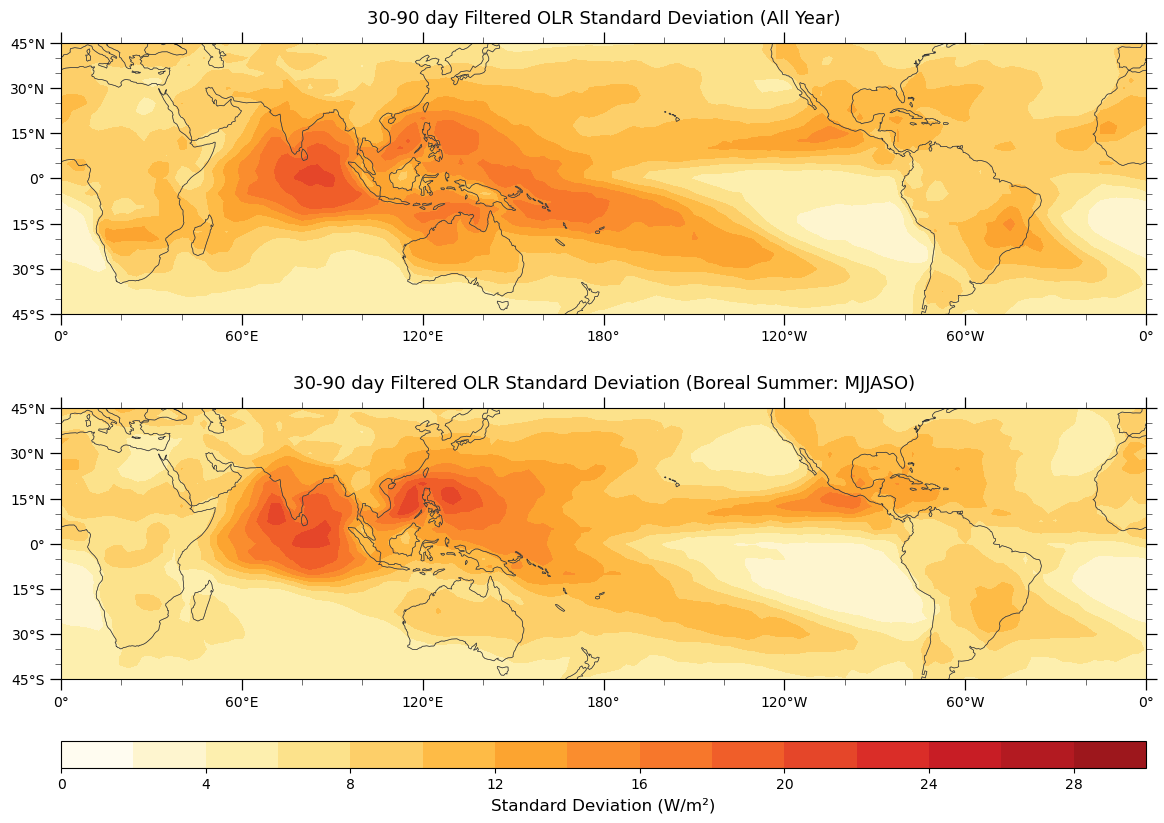

In [38]:
def plot_spatial_comparison(
    data_list,
    titles,
    levels=None,
    cmap='YlOrRd',
    extent=[0, 360, -45, 45],
    central_lon=180,
    cbar_label='',
    figsize=(14, 10),
    extend='both',
    add_contour=False,
    contour_levels=None,
    contour_colors='black',
    contour_linewidths=1.0,
    suptitle=None,
    use_geocat=True
):
    """
    通用的空间分布对比图绘制函数（支持geocat风格）
    
    Parameters
    ----------
    data_list : list of xr.DataArray
        要绘制的数据列表
    titles : list of str
        每个子图的标题
    levels : array-like, optional
        填色等级
    cmap : str or colormap
        色标
    extent : list
        地图范围 [lon_min, lon_max, lat_min, lat_max]
    central_lon : float
        中心经度
    cbar_label : str
        色标标签
    figsize : tuple
        图形大小
    extend : str
        色标延伸方向 ('both', 'min', 'max', 'neither')
    add_contour : bool
        是否添加等值线
    contour_levels : array-like, optional
        等值线等级
    contour_colors : str or list
        等值线颜色
    contour_linewidths : float or list
        等值线宽度
    suptitle : str, optional
        总标题
    use_geocat : bool
        是否使用geocat.viz工具（需要导入geocat.viz）
        
    Returns
    -------
    fig, axes : matplotlib figure and axes
    """
    # 尝试导入geocat.viz
    if use_geocat:
        try:
            import geocat.viz as gv
        except ImportError:
            print("⚠️ geocat.viz未安装，使用标准绘图方式")
            use_geocat = False
    
    n_plots = len(data_list)
    
    # 使用正确的中心经度投影
    fig, axes = plt.subplots(
        n_plots, 1, 
        figsize=figsize,
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=central_lon)}
    )
    
    # 确保axes是列表
    if n_plots == 1:
        axes = [axes]
    
    # 如果未指定levels，从第一个数据自动生成
    if levels is None:
        vmin, vmax = float(data_list[0].min()), float(data_list[0].max())
        levels = np.linspace(vmin, vmax, 21)
    
    cf_list = []
    
    for i, (data, title, ax) in enumerate(zip(data_list, titles, axes)):
        
        # 使用geocat添加循环经度（如果需要）
        if use_geocat:
            try:
                data = gv.xr_add_cyclic_longitudes(data, 'lon')
            except:
                pass
        
        # 绘制填色图
        cf = ax.contourf(
            data.lon,
            data.lat,
            data,
            levels=levels,
            cmap=cmap,
            extend=extend,
            transform=ccrs.PlateCarree()
        )
        cf_list.append(cf)
        
        # 添加等值线（可选）
        if add_contour:
            c_levels = contour_levels if contour_levels is not None else levels
            ax.contour(
                data.lon,
                data.lat,
                data,
                levels=c_levels,
                colors=contour_colors,
                linewidths=contour_linewidths,
                transform=ccrs.PlateCarree()
            )
        
        # 使用geocat设置坐标轴
        if use_geocat:
            # 设置坐标范围和刻度
            lon_range = extent[0:2]
            lat_range = extent[2:4]
            
            # 自动生成合理的刻度（考虑中心经度）
            lon_step = 60 if (lon_range[1] - lon_range[0]) > 270 else 30
            lat_step = 15 if (lat_range[1] - lat_range[0]) > 60 else 10
            
            # 调整经度范围以匹配central_lon投影
            # 当central_lon=180时，范围应该是[-180, 180]对应[0, 360]
            if central_lon == 180:
                xlim = (lon_range[0] - 180, lon_range[1] - 180)
                xticks_vals = np.arange(lon_range[0], lon_range[1] + 1, lon_step) - 180
            else:
                xlim = lon_range
                xticks_vals = np.arange(lon_range[0], lon_range[1] + 1, lon_step)
            
            gv.set_axes_limits_and_ticks(
                ax,
                xlim=xlim,
                ylim=lat_range,
                xticks=xticks_vals,
                yticks=np.arange(lat_range[0], lat_range[1] + 1, lat_step)
            )
            
            # 添加主次刻度
            gv.add_major_minor_ticks(ax, labelsize=10)
            
            # 添加经纬度标签
            gv.add_lat_lon_ticklabels(ax)
            
            # 移除右侧和顶部标签
            ax.tick_params(labeltop=False, labelright=False)
        else:
            # 标准方式设置地图
            ax.set_extent(extent, crs=ccrs.PlateCarree())
            
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
        
        # 地图要素
        # ax.coastlines(linewidth=0.8)
        # ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
        ax.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=1)
        ax.coastlines(linewidth=0.5, alpha=0.6)

        # 标题
        gv.set_titles_and_labels(ax, maintitle=title, maintitlefontsize=13) if use_geocat else ax.set_title(title, fontsize=13, fontweight='bold')
    
    # 统一色标
    cbar = fig.colorbar(
        cf_list[-1], 
        ax=axes, 
        orientation='horizontal',
        fraction=0.05, 
        pad=0.08, 
        aspect=40,
        drawedges=False
    )
    cbar.set_label(cbar_label, fontsize=12)
    cbar.ax.tick_params(labelsize=10)
    
    # 总标题
    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight='bold', y=0.995)
    
    
    return fig, axes



# 使用新函数绘制OLR标准差对比图（geocat风格）
fig, axes = plot_spatial_comparison(
    data_list=[olr_filtered_std_all, olr_filtered_std_summer],
    titles=[
        '30-90 day Filtered OLR Standard Deviation (All Year)',
        '30-90 day Filtered OLR Standard Deviation (Boreal Summer: MJJASO)'
    ],
    levels=np.arange(0, 32, 2),
    cmap=cmaps.WhiteYellowOrangeRed,
    extent=[0, 360, -45, 45],
    cbar_label='Standard Deviation (W/m²)',
    figsize=(14, 10),
    extend='neither',
    use_geocat=True  
)
plt.show()



In [39]:
# 3. EOF分析准备
from xeofs.single import EOF

# 定义热带区域进行EOF分析
lat_bounds = (-10, 40)
lon_bounds = (40, 160)

# 提取热带区域数据（注意lat坐标可能是降序的）
lat_vals = olr_filtered.lat.values
if lat_vals[0] > lat_vals[-1]:
    # 降序：从大到小
    lat_sl = slice(lat_bounds[1], lat_bounds[0])
else:
    # 升序：从小到大
    lat_sl = slice(lat_bounds[0], lat_bounds[1])

olr_tropical = olr_filtered.sel(
    lat=lat_sl,
    lon=slice(lon_bounds[0], lon_bounds[1])
)

olr_tropical_summer = olr_filtered_summer.sel(
    lat=lat_sl,
    lon=slice(lon_bounds[0], lon_bounds[1])
)

print(f"全年数据 EOF 输入: {olr_tropical.shape}")
print(f"夏季数据 EOF 输入: {olr_tropical_summer.shape}")

全年数据 EOF 输入: (13149, 21, 49)
夏季数据 EOF 输入: (6624, 21, 49)


In [40]:
# 5. 执行EOF分析 - 夏季数据

eof_summer = EOF(n_modes=5, use_coslat=True)
eof_summer.fit(olr_tropical_summer, dim='time')

# 提取前两个模态
eof1_summer = eof_summer.components().sel(mode=1)
eof2_summer = eof_summer.components().sel(mode=2)

# 解释方差
var_exp_summer = eof_summer.explained_variance_ratio().values * 100

print(f"\nEOF1 解释方差: {var_exp_summer[0]:.2f}%")
print(f"EOF2 解释方差: {var_exp_summer[1]:.2f}%")
print(f"前两个模态总计: {var_exp_summer[0] + var_exp_summer[1]:.2f}%")


EOF1 解释方差: 16.71%
EOF2 解释方差: 11.09%
前两个模态总计: 27.80%


In [41]:
olr_tropical

<xarray.DataArray 'olr_anomaly_geocat_fourier' (time: 13149, lat: 21, lon: 49)> Size: 54MB
array([[[ -5.718354  ,  -3.1004858 ,   3.6857476 , ...,  12.765128  ,
          12.061644  ,   8.538859  ],
        [ -1.4109212 ,  -2.9960375 ,   5.894845  , ...,  13.187585  ,
          10.437447  ,  11.443866  ],
        [  4.092633  ,   5.26562   ,   4.2945814 , ...,   3.013227  ,
           5.2528706 ,   9.934875  ],
        ...,
        [  7.6747065 ,   9.657631  ,  15.214644  , ..., -27.766207  ,
         -36.06243   , -33.640545  ],
        [ 13.491136  ,  14.7227125 ,  12.635164  , ..., -19.686451  ,
         -22.14044   , -20.895782  ],
        [ 12.165295  ,   6.809656  ,  11.231398  , ..., -12.663352  ,
         -11.46451   ,  -8.811128  ]],

       [[ -5.8496294 ,  -3.2350252 ,   2.7913308 , ...,  12.90473   ,
          12.070487  ,   8.705054  ],
        [ -2.2944756 ,  -3.9400704 ,   5.061611  , ...,  14.722692  ,
          12.113297  ,  13.08505   ],
        [  2.5248604 ,   4.007469  ,   3.3642104 , ...,   4.992533  ,
           7.5103946 ,  12.026639  ],
...
        [  8.876913  ,  10.815487  ,  18.054077  , ..., -23.224133  ,
         -31.360037  , -27.927872  ],
        [ 14.541729  ,  16.306536  ,  13.800722  , ..., -11.785631  ,
         -14.704942  , -15.157287  ],
        [ 12.670283  ,   5.6239114 ,  10.812575  , ...,  -4.445804  ,
          -3.248269  ,  -2.7805235 ]],

       [[ -5.368359  ,  -2.8496807 ,   4.502206  , ...,  12.570952  ,
          11.974077  ,   8.344903  ],
        [ -0.41323784,  -1.9802558 ,   6.554696  , ...,  11.584391  ,
           8.757551  ,   9.702282  ],
        [  5.597015  ,   6.3739986 ,   5.079016  , ...,   1.164624  ,
           3.044623  ,   7.756486  ],
        ...,
        [  8.2740555 ,  10.246815  ,  16.720201  , ..., -25.700672  ,
         -34.02694   , -31.034853  ],
        [ 14.042052  ,  15.611655  ,  13.299196  , ..., -15.778311  ,
         -18.542116  , -18.16591   ],
        [ 12.3379135 ,   6.187837  ,  11.095987  , ...,  -8.617768  ,
          -7.3613544 ,  -5.7988787 ]]], dtype=float32)
Coordinates:
    dayofyear  (time) int64 105kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * time       (time) datetime64[ns] 105kB 1979-01-01 1979-01-02 ... 2014-12-31
  * lon        (lon) float32 196B 40.0 42.5 45.0 47.5 ... 155.0 157.5 160.0
  * lat        (lat) float32 84B 40.0 37.5 35.0 32.5 ... -2.5 -5.0 -7.5 -10.0
Attributes:
    units:         W/m^2
    var_desc:      Outgoing Longwave Radiation
    precision:     2
    dataset:       NOAA Interpolated OLR
    level_desc:    Other
    statistic:     Mean
    parent_stat:   Individual Obs
    valid_range:   [  0. 500.]
    long_name:     30-90 day fourier_band_pass (geocat)
    actual_range:  [ 64.75 344.5 ]

In [42]:
eof_all = EOF(n_modes=5, use_coslat=True)
eof_all.fit(olr_filtered, dim='time')

# 提取前两个模态
eof1_all = eof_all.components().sel(mode=1)
eof2_all = eof_all.components().sel(mode=2)

# 解释方差
var_exp_all = eof_all.explained_variance_ratio().values * 100

print(f"\nEOF1 解释方差: {var_exp_all[0]:.2f}%")
print(f"EOF2 解释方差: {var_exp_all[1]:.2f}%")
print(f"前两个模态总计: {var_exp_all[0] + var_exp_all[1]:.2f}%")


EOF1 解释方差: 6.49%
EOF2 解释方差: 5.39%
前两个模态总计: 11.88%


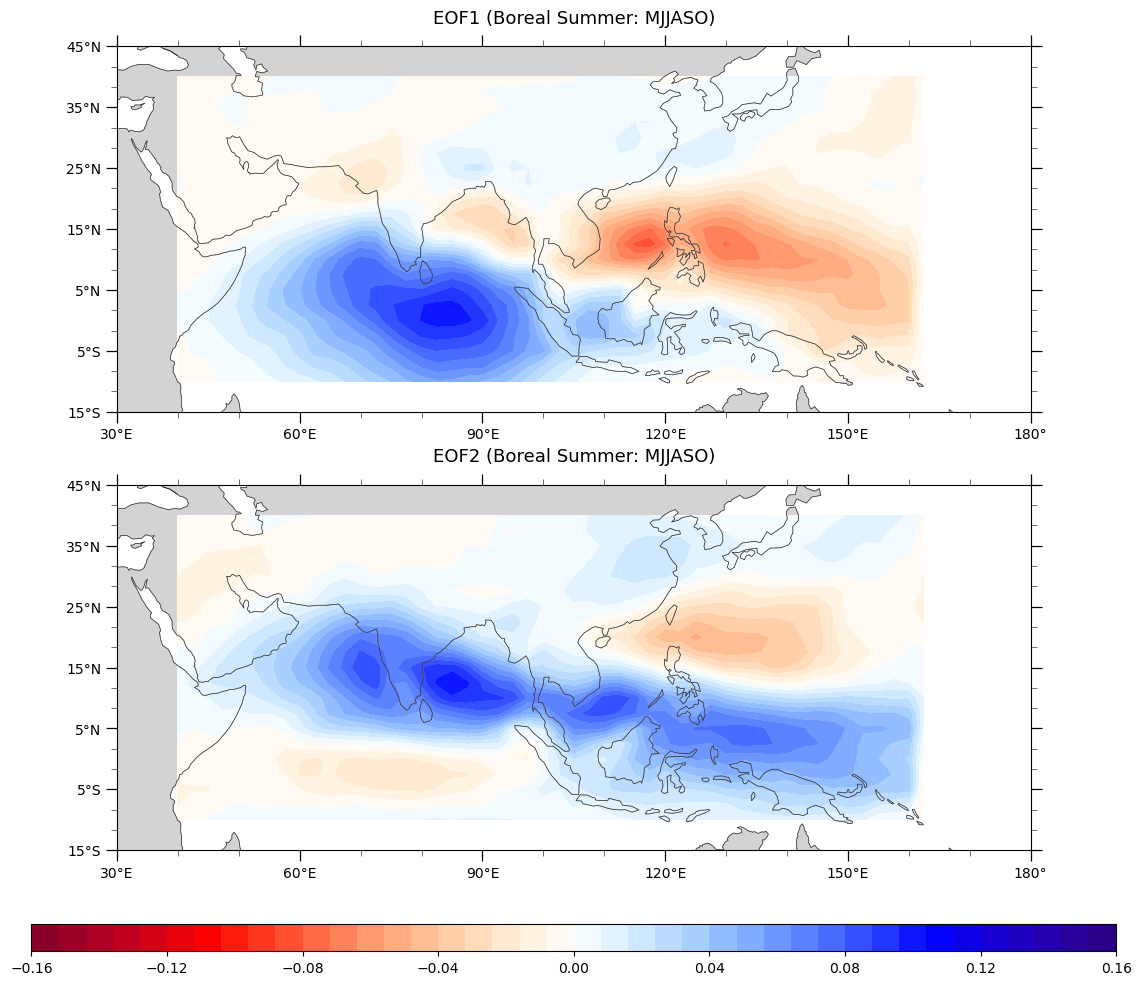

In [43]:
fig, axes = plot_spatial_comparison(
    data_list=[eof1_summer, eof2_summer],
    titles=[
        'EOF1 (Boreal Summer: MJJASO)',
        'EOF2 (Boreal Summer: MJJASO)'
    ],
    levels=np.linspace(-0.16, 0.16, 41),
    cmap=cmaps.NCV_blu_red_r,
    extent=[30, 180, -15, 45],
    cbar_label='',
    figsize=(14, 12),
    extend='neither',
    use_geocat=True  
)
plt.show()

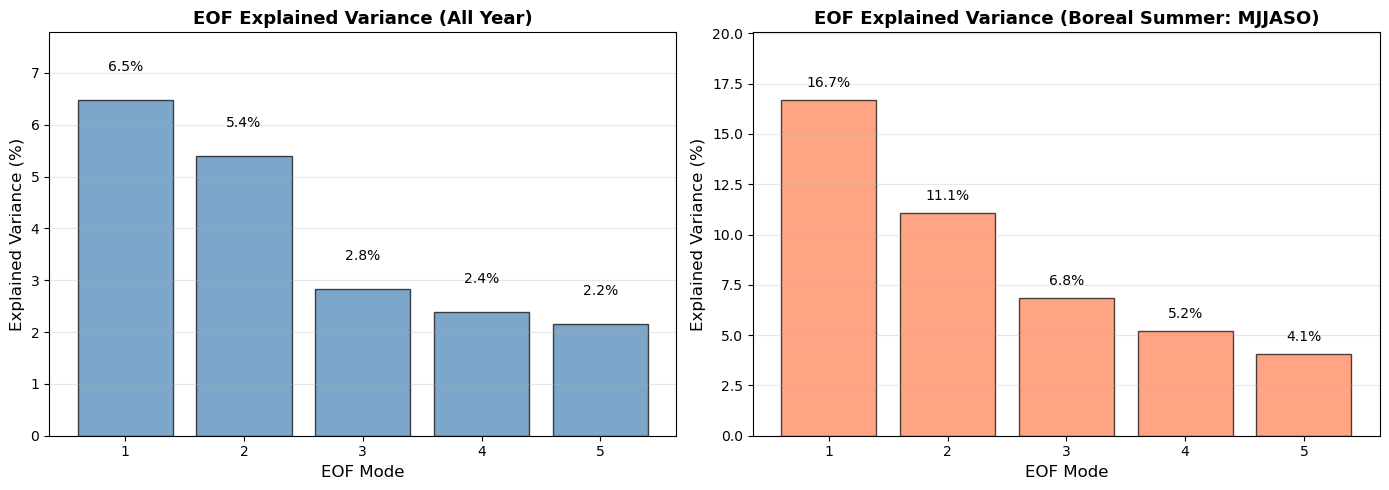

In [44]:
# 8. 绘制解释方差对比柱状图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

modes = np.arange(1, 6)

# 全年数据
ax1.bar(modes, var_exp_all[:5], color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('EOF Mode', fontsize=12)
ax1.set_ylabel('Explained Variance (%)', fontsize=12)
ax1.set_title('EOF Explained Variance (All Year)', fontsize=13, fontweight='bold')
ax1.set_xticks(modes)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(var_exp_all[:5]) * 1.2)

# 在柱子上标注数值
for i, v in enumerate(var_exp_all[:5]):
    ax1.text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

# 夏季数据
ax2.bar(modes, var_exp_summer[:5], color='coral', alpha=0.7, edgecolor='black')
ax2.set_xlabel('EOF Mode', fontsize=12)
ax2.set_ylabel('Explained Variance (%)', fontsize=12)
ax2.set_title('EOF Explained Variance (Boreal Summer: MJJASO)', fontsize=13, fontweight='bold')
ax2.set_xticks(modes)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(var_exp_summer[:5]) * 1.2)

# 在柱子上标注数值
for i, v in enumerate(var_exp_summer[:5]):
    ax2.text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


### EOF分析结果对比

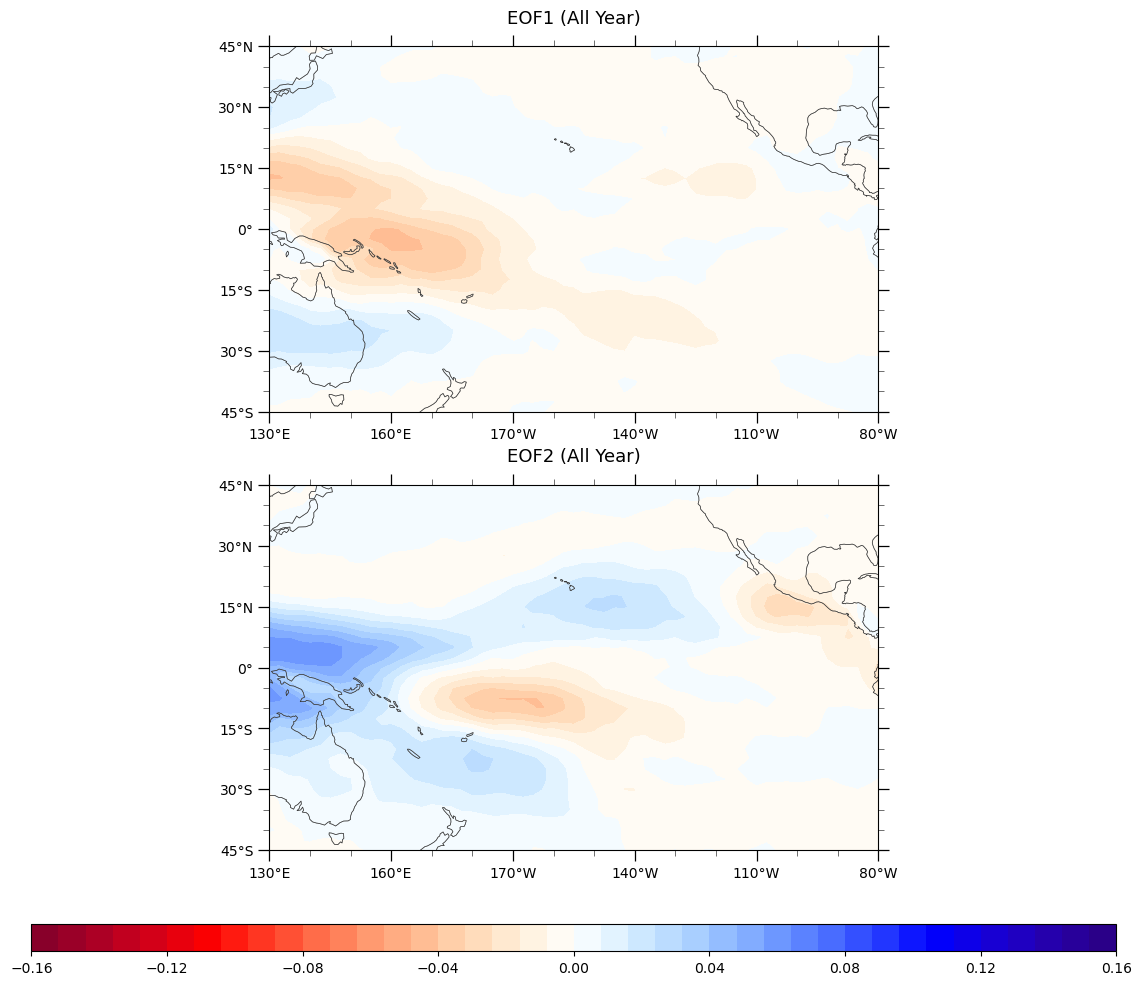

In [45]:
fig, axes = plot_spatial_comparison(
    data_list=[eof1_all, eof2_all],
    titles=[
        'EOF1 (All Year)',
        'EOF2 (All Year)'
    ],
    levels=np.linspace(-0.16, 0.16, 41),
    cmap=cmaps.NCV_blu_red_r,
    extent=[30, 180, -45, 45],  # 修复：使用区域范围避免投影问题
    central_lon=100,  # 修复：调整中心经度匹配extent
    cbar_label='',
    figsize=(14, 12),
    extend='neither',
    use_geocat=True  
)
plt.show()

In [46]:
# 4. 执行EOF分析 - 全年数据
print("="*60)
print("全年数据EOF分析（1979-2014）")
print("="*60)

eof_all = EOF(n_modes=5, use_coslat=True)
eof_all.fit(olr_tropical, dim='time')

# 提取前两个模态
eof1_all = eof_all.components().sel(mode=1)
eof2_all = eof_all.components().sel(mode=2)

# 解释方差
var_exp_all = eof_all.explained_variance_ratio().values * 100

print(f"\nEOF1 解释方差: {var_exp_all[0]:.2f}%")
print(f"EOF2 解释方差: {var_exp_all[1]:.2f}%")
print(f"前两个模态总计: {var_exp_all[0] + var_exp_all[1]:.2f}%")

全年数据EOF分析（1979-2014）

EOF1 解释方差: 17.00%
EOF2 解释方差: 10.85%
前两个模态总计: 27.85%

EOF1 解释方差: 17.00%
EOF2 解释方差: 10.85%
前两个模态总计: 27.85%


## identify individual BSISO event

In [53]:

# ── Step 1: 提取赤道IO区域平均指数（全年，用于后续season筛选）
io_index = extract_io_index(olr_filtered)

# ── Step 2: 仅保留北半球夏季（MJJASO）
io_index_summer = select_boreal_summer(io_index)

# ── Step 3: 识别 BSISO 事件，返回事件列表和阈值
bsiso_events, threshold = identify_bsiso_events(
    io_index_summer,
    threshold_std=1.0,
)

# ── Step 4: 打印事件表
print_event_table(bsiso_events)


IO index  mean = 0.015 W/m²
IO index  std  = 12.888  W/m²
Threshold      = -12.888  W/m²  (mean − 1.0σ)
Bsiso event start: 1979-05-01T00:00:00.000000000 
 Bsiso event minimum: 1979-05-05T00:00:00.000000000 
 Bsiso event end: 1979-05-10T00:00:00.000000000 -1 days
Bsiso event start: 1979-06-09T00:00:00.000000000 
 Bsiso event minimum: 1979-05-04T00:00:00.000000000 
 Bsiso event end: 1979-06-18T00:00:00.000000000 -1 days
Bsiso event start: 1979-09-03T00:00:00.000000000 
 Bsiso event minimum: 1979-05-08T00:00:00.000000000 
 Bsiso event end: 1979-09-18T00:00:00.000000000 -1 days
Bsiso event start: 1980-07-18T00:00:00.000000000 
 Bsiso event minimum: 1979-05-06T00:00:00.000000000 
 Bsiso event end: 1980-07-30T00:00:00.000000000 -1 days
Bsiso event start: 1980-09-30T00:00:00.000000000 
 Bsiso event minimum: 1979-05-10T00:00:00.000000000 
 Bsiso event end: 1980-10-19T00:00:00.000000000 -1 days
Bsiso event start: 1981-05-10T00:00:00.000000000 
 Bsiso event minimum: 1979-05-08T00:00:00.000000000

In [54]:
bsiso_events

[{'day0': np.datetime64('1979-05-05T00:00:00.000000000'),
  'day0_value': -16.901294708251953,
  'event_slice': slice('1979-05-01', '1979-05-09', None)},
 {'day0': np.datetime64('1979-06-12T00:00:00.000000000'),
  'day0_value': -17.95491600036621,
  'event_slice': slice('1979-06-09', '1979-06-17', None)},
 {'day0': np.datetime64('1979-09-10T00:00:00.000000000'),
  'day0_value': -21.25421905517578,
  'event_slice': slice('1979-09-03', '1979-09-17', None)},
 {'day0': np.datetime64('1980-07-23T00:00:00.000000000'),
  'day0_value': -18.616989135742188,
  'event_slice': slice('1980-07-18', '1980-07-29', None)},
 {'day0': np.datetime64('1980-10-09T00:00:00.000000000'),
  'day0_value': -23.094959259033203,
  'event_slice': slice('1980-09-30', '1980-10-18', None)},
 {'day0': np.datetime64('1981-05-17T00:00:00.000000000'),
  'day0_value': -33.004844665527344,
  'event_slice': slice('1981-05-10', '1981-05-24', None)},
 {'day0': np.datetime64('1981-07-21T00:00:00.000000000'),
  'day0_value': -31.

## BSISO合成分析 (Composite Analysis)

基于识别的BSISO事件，进行超前-滞后合成分析，揭示其演变特征

In [55]:

def create_lagged_composite(
    data, 
    events, 
    lag_range=(-20, 20),
    min_duration=10
):
    """
    创建超前-滞后合成分析
    
    Parameters
    ----------
    data : xr.DataArray (time, lat, lon)
        滤波后的OLR场或其他变量
    events : list of dict
        BSISO事件列表，每个包含'day0'（参考日期）
    lag_range : tuple
        超前滞后范围（天），如(-20, 20)表示day0前后各20天
    min_duration : int
        事件最短持续时间（天），用于筛选
        
    Returns
    -------
    composite : xr.DataArray (lag, lat, lon)
        合成场，lag维度为超前滞后天数
    """
    
    # 筛选有效事件（持续时间足够长）
    valid_events = []
    for ev in events:
        # 计算事件持续时间
        start = pd.Timestamp(str(ev['event_slice']).split("'")[1])
        end = pd.Timestamp(str(ev['event_slice']).split("'")[3])
        duration = (end - start).days + 1
        
        if duration >= min_duration:
            valid_events.append(ev)
    
    print(f"筛选后有效事件数: {len(valid_events)}/{len(events)} (持续≥{min_duration}天)")
    
    # 创建超前滞后序列
    lags = np.arange(lag_range[0], lag_range[1] + 1)
    composites = []
    
    for lag in lags:
        lag_samples = []
        
        for ev in valid_events:
            day0 = pd.Timestamp(ev['day0'])
            target_day = day0 + pd.Timedelta(days=int(lag))
            
            # 检查目标日期是否在数据范围内
            if target_day in data.time.values:
                lag_samples.append(data.sel(time=target_day))
        
        if len(lag_samples) > 0:
            # 计算该lag的合成平均
            composite_lag = xr.concat(lag_samples, dim='sample').mean(dim='sample')
            composites.append(composite_lag)
        else:
            # 如果没有样本，填充NaN
            composites.append(data.isel(time=0) * np.nan)
    
    # 合并为完整的composite数组
    composite = xr.concat(composites, dim='lag')
    composite = composite.assign_coords(lag=lags)
    composite.attrs['long_name'] = f'Composite {data.name}'
    composite.attrs['n_events'] = len(valid_events)
    
    return composite, valid_events

In [56]:
# 执行合成分析
composite_olr, valid_events = create_lagged_composite(
    olr_filtered_summer.sel(lon=slice(40, 200)), 
    bsiso_events,
    lag_range=(-50, 50),
    min_duration=5
)

print(f"\n合成场维度: {composite_olr.shape}")
print(f"有效事件数: {len(valid_events)}")

筛选后有效事件数: 80/92 (持续≥5天)

合成场维度: (101, 73, 65)
有效事件数: 80

合成场维度: (101, 73, 65)
有效事件数: 80


In [57]:
composite_olr

<xarray.DataArray 'olr_anomaly_geocat_fourier' (lag: 101, lat: 73, lon: 65)> Size: 2MB
array([[[ 0.96532446,  0.96532446,  0.96532446, ...,  0.96532446,
          0.96532446,  0.96532446],
        [ 0.53818405,  0.5387546 ,  0.5369478 , ...,  0.7138428 ,
          0.6551889 ,  0.61707   ],
        [ 0.26462802,  0.36512372,  0.3851842 , ...,  0.22841997,
          0.17887916,  0.13289149],
        ...,
        [-1.9353765 , -1.9200042 , -1.9163654 , ...,  0.3641131 ,
          0.39327636,  0.39763206],
        [-1.6025034 , -1.6235926 , -1.6861457 , ..., -0.58387506,
         -0.5747907 , -0.58182853],
        [-1.5914588 , -1.5914588 , -1.5914588 , ..., -1.5914588 ,
         -1.5914588 , -1.5914588 ]],

       [[ 0.9856889 ,  0.9856889 ,  0.9856889 , ...,  0.9856889 ,
          0.9856889 ,  0.9856889 ],
        [ 0.51494396,  0.51609665,  0.50804085, ...,  0.768524  ,
          0.7050667 ,  0.66615176],
        [ 0.2279749 ,  0.32720652,  0.34925625, ...,  0.32451436,
          0.27158478,  0.22115126],
...
        [-0.13593236, -0.14462025, -0.15166278, ..., -0.48511136,
         -0.490399  , -0.4927146 ],
        [ 0.08330979,  0.07564089,  0.07885098, ..., -0.04206713,
         -0.03327674, -0.03686402],
        [ 0.2064373 ,  0.2064373 ,  0.2064373 , ...,  0.2064373 ,
          0.2064373 ,  0.2064373 ]],

       [[-0.42602175, -0.42602175, -0.42602175, ..., -0.42602175,
         -0.42602175, -0.42602175],
        [-0.40584832, -0.39380634, -0.37179765, ..., -0.3266752 ,
         -0.34580302, -0.35363433],
        [-0.7352238 , -0.38603246, -0.3861221 , ..., -0.11226643,
         -0.14664914, -0.17682996],
        ...,
        [-0.08544196, -0.0944435 , -0.1054868 , ..., -0.34774354,
         -0.35212663, -0.3624453 ],
        [ 0.16996464,  0.16058858,  0.16807441, ...,  0.01531809,
          0.02456047,  0.01569141],
        [ 0.24615546,  0.24615546,  0.24615546, ...,  0.24615546,
          0.24615546,  0.24615546]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 260B 40.0 42.5 45.0 47.5 ... 192.5 195.0 197.5 200.0
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lag      (lag) int64 808B -50 -49 -48 -47 -46 -45 -44 ... 45 46 47 48 49 50
Attributes:
    units:         W/m^2
    var_desc:      Outgoing Longwave Radiation
    precision:     2
    dataset:       NOAA Interpolated OLR
    level_desc:    Other
    statistic:     Mean
    parent_stat:   Individual Obs
    valid_range:   [  0. 500.]
    long_name:     Composite olr_anomaly_geocat_fourier
    actual_range:  [ 64.75 344.5 ]
    n_events:      80

### 1. Hovmöller图：展示东传特征

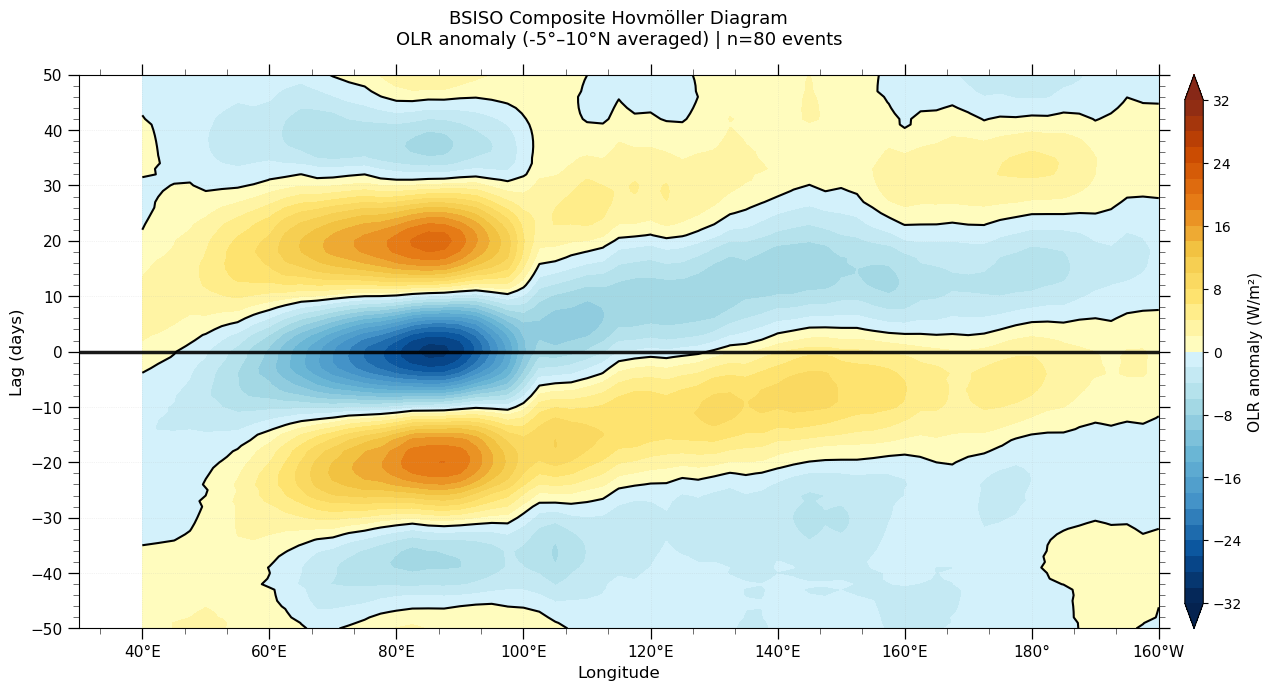

In [58]:
def plot_hovmoller_composite(composite, lat_range=(-5, 10), cmap = 'bwr' ,extent=[50,180],use_geocat=True):
    """
    绘制经度-时间Hovmöller图，展示BSISO东传特征（支持geocat风格）
    
    Parameters
    ----------
    composite : xr.DataArray (lag, lat, lon)
    lat_range : tuple
        纬度平均范围
    use_geocat : bool
        是否使用geocat.viz风格
    """
    # 尝试导入geocat.viz
    if use_geocat:
        try:
            import geocat.viz as gv
            from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
        except ImportError:
            print("⚠️ geocat.viz未安装，使用标准绘图方式")
            use_geocat = False
    
    # 纬度平均
    lat_vals = composite.lat.values
    if lat_vals[0] > lat_vals[-1]:
        lat_sl = slice(lat_range[1], lat_range[0])
    else:
        lat_sl = slice(lat_range[0], lat_range[1])
    
    hov_data = composite.sel(lat=lat_sl).mean(dim='lat')
    
    # 绘图
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # 使用contourf绘制
    levels = np.arange(-32, 34, 2)
    cf = ax.contourf(
        hov_data.lon, 
        hov_data.lag,
        hov_data,
        levels=levels,
        cmap=cmap,
        extend='both'
    )
    
    # 添加零线
    ax.contour(
        hov_data.lon, 
        hov_data.lag,
        hov_data,
        levels=[0],
        colors='black',
        linewidths=1.5
    )
    
    # 添加参考线
    ax.axhline(0, color='black', linewidth=2.5, linestyle='-', alpha=0.9, zorder=3)
    
    # 使用geocat设置坐标轴
    if use_geocat:
        # 设置坐标范围和刻度
        lon_min, lon_max = float(hov_data.lon.min()), float(hov_data.lon.max())
        lag_min, lag_max = float(hov_data.lag.min()), float(hov_data.lag.max())
        
        # 自动生成刻度
        lon_step = 30 if (lon_max - lon_min) > 180 else 20
        lag_step = 10 if (lag_max - lag_min) > 40 else 5
        
        gv.set_axes_limits_and_ticks(
            ax,
            xlim=(lon_min, lon_max),
            ylim=(lag_min, lag_max),
            xticks=np.arange(0, 361, lon_step),
            yticks=np.arange(lag_min, lag_max + 1, lag_step)
        )
        
        # 添加主次刻度
        gv.add_major_minor_ticks(ax, x_minor_per_major=3, y_minor_per_major=5, labelsize=11)
        
        # 设置标签
        gv.set_titles_and_labels(
            ax,
            xlabel='Longitude',
            ylabel='Lag (days)',
            maintitle=f'BSISO Composite Hovmöller Diagram\n'
                     f'OLR anomaly ({lat_range[0]}°–{lat_range[1]}°N averaged) | '
                     f'n={composite.attrs["n_events"]} events',
            maintitlefontsize=13,
            labelfontsize=12
        )
        ax.set_xlim(extent[0],extent[1])
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label =False))
    else:
        # 标准方式
        ax.set_xlabel('Longitude (°E)', fontsize=12)
        ax.set_ylabel('Lag (days)', fontsize=12)
        ax.set_title(
            f'BSISO Composite Hovmöller Diagram\n'
            f'OLR anomaly ({lat_range[0]}°–{lat_range[1]}°N averaged)\n'
            f'n={composite.attrs["n_events"]} events',
            fontsize=13,
            fontweight='bold'
        )
        ax.set_ylim(hov_data.lag.min(), hov_data.lag.max())
    
    # 网格
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=1)
    
    # 色标
    cbar = plt.colorbar(cf, ax=ax, orientation='vertical', 
                       pad=0.02, aspect=30, drawedges=False)
    cbar.set_label('OLR anomaly (W/m²)', fontsize=11)
    cbar.ax.tick_params(labelsize=10)
    
    plt.tight_layout()
    return fig

# 绘制Hovmöller图（geocat风格）
fig_hov = plot_hovmoller_composite(composite_olr, lat_range=(-5, 10),
                                   cmap = cmaps.BlueYellowRed,
                                   extent=[30, 200], use_geocat=True)
plt.show()

### 2. 空间演变图：关键阶段的OLR分布

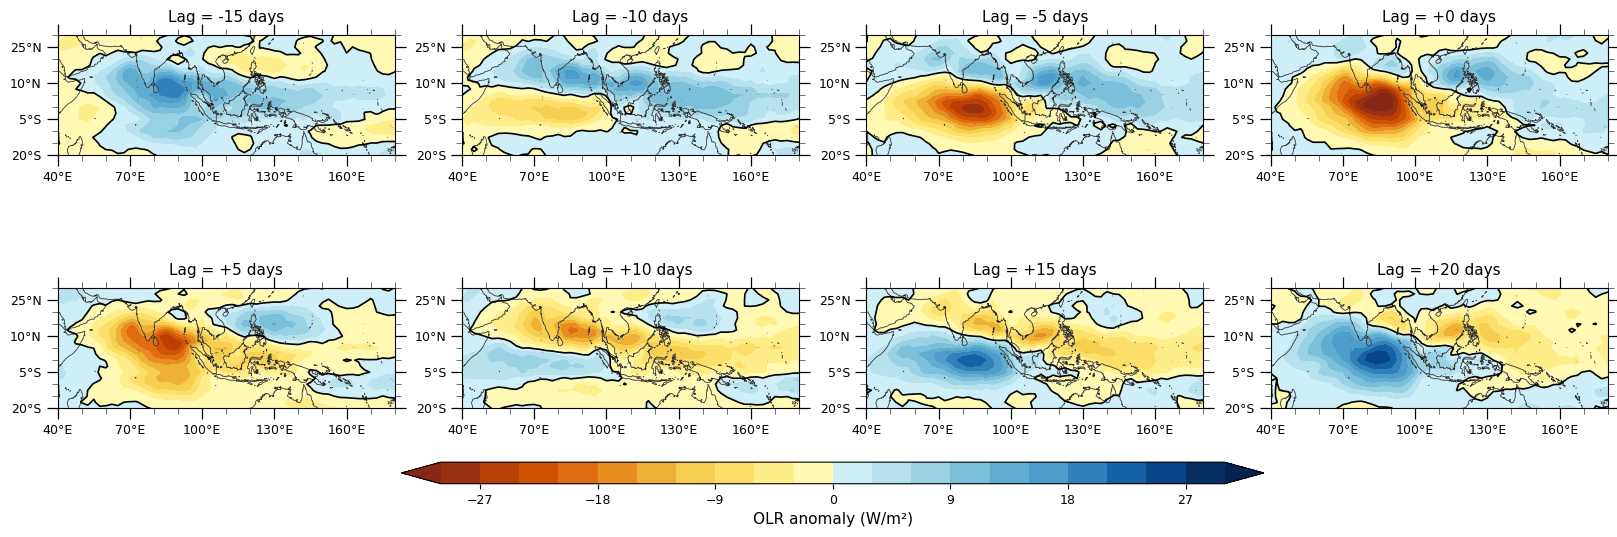

In [59]:
def plot_spatial_evolution(composite, lags_to_plot=[-15, -10, -5, 0, 5, 10, 15], 
                          use_geocat=True, cmap='RdBu_r', extent=[40, 180, -20, 30],
                          central_lon=120):
    """
    绘制不同lag时刻的OLR空间分布，展示BSISO演变过程（支持geocat风格）
    
    Parameters
    ----------
    composite : xr.DataArray (lag, lat, lon)
    lags_to_plot : list
        要绘制的lag时刻列表
    use_geocat : bool
        是否使用geocat.viz风格
    cmap : str or colormap
        色标
    extent : list
        地图范围 [lon_min, lon_max, lat_min, lat_max]
    central_lon : float
        中心经度
    """
    # 尝试导入geocat.viz
    if use_geocat:
        try:
            import geocat.viz as gv
        except ImportError:
            print("⚠️ geocat.viz未安装，使用标准绘图方式")
            use_geocat = False
    
    n_panels = len(lags_to_plot)
    ncols = 4
    nrows = int(np.ceil(n_panels / ncols))
    
    fig = plt.figure(figsize=(20, nrows * 3.5), dpi=100)
    
    for i, lag in enumerate(lags_to_plot, 1):
        ax = fig.add_subplot(nrows, ncols, i, 
                            projection=ccrs.PlateCarree(central_longitude=central_lon))
        
        # 选择数据
        data_plot = composite.sel(lag=lag)
        
        # 使用geocat添加循环经度
        if use_geocat:
            try:
                data_plot = gv.xr_add_cyclic_longitudes(data_plot, 'lon')
            except:
                pass
        
        # 绘制填色图
        levels = np.arange(-30, 33, 3)
        cf = ax.contourf(
            data_plot.lon,
            data_plot.lat,
            data_plot,
            levels=levels,
            cmap=cmap,
            extend='both',
            transform=ccrs.PlateCarree()
        )
        
        # 添加零线
        ax.contour(
            data_plot.lon,
            data_plot.lat,
            data_plot,
            levels=[0],
            colors='black',
            linewidths=1.2,
            transform=ccrs.PlateCarree()
        )
        
        # 使用geocat设置坐标轴
        if use_geocat:
            lon_range = extent[0:2]
            lat_range = extent[2:4]
            
            # 自动生成刻度
            lon_step = 30 if (lon_range[1] - lon_range[0]) > 100 else 20
            lat_step = 15 if (lat_range[1] - lat_range[0]) > 40 else 10
            
            # 调整经度范围以匹配central_lon投影
            if central_lon == 180:
                xlim = (lon_range[0] - 180, lon_range[1] - 180)
                xticks_vals = np.arange(lon_range[0], lon_range[1] + 1, lon_step) - 180
            elif central_lon == 120:
                # 对于120°中心，将[40, 180]映射到[-80, 60]
                xlim = (lon_range[0] - central_lon, lon_range[1] - central_lon)
                xticks_vals = np.arange(lon_range[0], lon_range[1] + 1, lon_step) - central_lon
            else:
                xlim = lon_range
                xticks_vals = np.arange(lon_range[0], lon_range[1] + 1, lon_step)
            
            gv.set_axes_limits_and_ticks(
                ax,
                xlim=xlim,
                ylim=lat_range,
                xticks=xticks_vals,
                yticks=np.arange(lat_range[0], lat_range[1] + 1, lat_step)
            )
            
            # 添加主次刻度
            gv.add_major_minor_ticks(ax, labelsize=9)
            
            # 添加经纬度标签
            gv.add_lat_lon_ticklabels(ax)
            
            # 移除右侧和顶部标签
            ax.tick_params(labeltop=False, labelright=False)
            ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
            ax.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=1)
            ax.coastlines(linewidth=0.5, alpha=0.6)
        else:
            # 标准方式设置地图
            ax.set_extent(extent, crs=ccrs.PlateCarree())
            
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
        
        
        # 标题
        if use_geocat:
            gv.set_titles_and_labels(ax, maintitle=f'Lag = {lag:+d} days', 
                                    maintitlefontsize=11)
        else:
            ax.set_title(f'Lag = {lag:+d} days', fontsize=11, fontweight='bold')
    
    
    # 统一色标
    cbar = fig.colorbar(
        cf, 
        ax=fig.get_axes(), 
        orientation='horizontal',
        fraction=0.04,
        pad=0.1,
        aspect=40,
        drawedges=False
    )
    cbar.set_label('OLR anomaly (W/m²)', fontsize=11)
    cbar.ax.tick_params(labelsize=9)
    
  
    return fig

# 绘制空间演变图（geocat风格）
fig_spatial = plot_spatial_evolution(
    composite_olr, 
    lags_to_plot=[-15, -10, -5, 0, 5, 10, 15, 20],
    use_geocat=True,
    cmap=cmaps.BlueYellowRed_r,
    extent=[40, 180, -20, 30],
    central_lon=120
)
plt.show()

### 3. 超前-滞后相关分析：传播特征量化

In [60]:
def lag_correlation_analysis(data, events, ref_box, lag_range=(-30, 30)):
    """
    计算参考区域与全球的超前-滞后相关，揭示传播路径
    
    Parameters
    ----------
    data : xr.DataArray (time, lat, lon)
        滤波后的OLR场
    events : list of dict
        BSISO事件列表
    ref_box : dict
        参考区域，格式 {'lat': (lat_min, lat_max), 'lon': (lon_min, lon_max)}
    lag_range : tuple
        超前滞后范围（天）
        
    Returns
    -------
    corr_map : xr.DataArray (lag, lat, lon)
        超前-滞后相关系数场
    """
    
    # 提取参考区域时间序列（所有夏季数据）
    lat_vals = data.lat.values
    if lat_vals[0] > lat_vals[-1]:
        lat_sl = slice(ref_box['lat'][1], ref_box['lat'][0])
    else:
        lat_sl = slice(ref_box['lat'][0], ref_box['lat'][1])
    
    ref_ts = data.sel(
        lat=lat_sl,
        lon=slice(ref_box['lon'][0], ref_box['lon'][1])
    ).mean(dim=['lat', 'lon'])
    
    # 计算超前-滞后相关（改用合成场方法，避免时间坐标重复）
    lags = np.arange(lag_range[0], lag_range[1] + 1)
    corr_maps = []
    
    print(f"计算超前-滞后相关: {len(lags)}个lag值...")
    
    for lag in lags:
        # 收集所有事件在该lag下的空间场
        lag_samples_data = []
        lag_samples_ref = []
        
        for ev in events:
            day0 = pd.Timestamp(ev['day0'])
            
            # 参考日期（day0）的参考区域值
            if day0 in ref_ts.time.values:
                ref_val = ref_ts.sel(time=day0)
                
                # lag日期的空间场
                lag_date = day0 + pd.Timedelta(days=int(lag))
                
                if lag_date in data.time.values:
                    lag_data = data.sel(time=lag_date)
                    
                    lag_samples_data.append(lag_data)
                    lag_samples_ref.append(ref_val)
        
        if len(lag_samples_data) > 1:
            # 将list转换为数组进行相关计算
            data_stack = xr.concat(lag_samples_data, dim='sample')
            ref_stack = xr.concat(lag_samples_ref, dim='sample')
            
            # 计算相关系数
            corr = xr.corr(ref_stack, data_stack, dim='sample')
            corr_maps.append(corr)
        else:
            # 样本不足，填充NaN
            corr_maps.append(data.isel(time=0) * np.nan)
    
    # 合并为完整数组
    corr_map = xr.concat(corr_maps, dim='lag')
    corr_map = corr_map.assign_coords(lag=lags)
    corr_map.attrs['long_name'] = 'Lag correlation'
    corr_map.attrs['reference_box'] = str(ref_box)
    
    print("✓ 超前-滞后相关计算完成")
    
    return corr_map

# 执行超前-滞后相关分析
ref_box = {'lat': (-5, 10), 'lon': (80, 100)}  # 印度洋参考区

# 只分析夏季数据
lag_corr = lag_correlation_analysis(
    olr_filtered_summer,
    valid_events,
    ref_box=ref_box,
    lag_range=(-40, 40)
)

print(f"超前-滞后相关场计算完成: {lag_corr.shape}")

计算超前-滞后相关: 81个lag值...
✓ 超前-滞后相关计算完成
超前-滞后相关场计算完成: (81, 73, 144)
✓ 超前-滞后相关计算完成
超前-滞后相关场计算完成: (81, 73, 144)


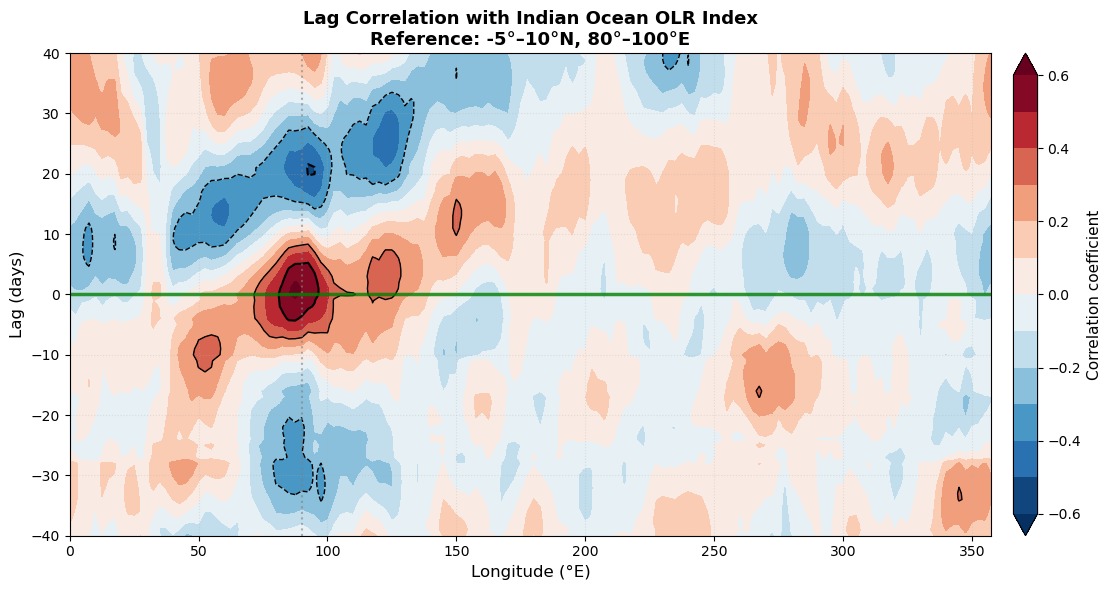

In [61]:
def plot_lag_correlation_hovmoller(lag_corr, lat_range=(-5, 10)):
    """绘制超前-滞后相关的Hovmöller图"""
    
    lat_vals = lag_corr.lat.values
    if lat_vals[0] > lat_vals[-1]:
        lat_sl = slice(lat_range[1], lat_range[0])
    else:
        lat_sl = slice(lat_range[0], lat_range[1])
    
    hov_data = lag_corr.sel(lat=lat_sl).mean(dim='lat')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 填色图
    levels = np.arange(-0.6, 0.7, 0.1)
    cf = ax.contourf(
        hov_data.lon,
        hov_data.lag,
        hov_data,
        levels=levels,
        cmap='RdBu_r',
        extend='both'
    )
    
    # 显著性标记（相关系数>0.3）
    ax.contour(
        hov_data.lon,
        hov_data.lag,
        hov_data,
        levels=[0.3, 0.5],
        colors='black',
        linewidths=[1.0, 1.5],
        linestyles='solid'
    )
    
    ax.contour(
        hov_data.lon,
        hov_data.lag,
        hov_data,
        levels=[-0.5, -0.3],  # 修改为升序
        colors='black',
        linewidths=[1.5, 1.0],  # 对应调整线宽
        linestyles='dashed'
    )
    
    # 参考线
    ax.axhline(0, color='green', linewidth=2.5, linestyle='-', alpha=0.8)
    ax.axvline(90, color='gray', linewidth=1.5, linestyle=':', alpha=0.6)
    
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    ax.set_ylabel('Lag (days)', fontsize=12)
    ax.set_title(
        f'Lag Correlation with Indian Ocean OLR Index\n'
        f'Reference: {lat_range[0]}°–{lat_range[1]}°N, 80°–100°E',
        fontsize=13,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3, linestyle=':')
    
    cbar = plt.colorbar(cf, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label('Correlation coefficient', fontsize=11)
    
    plt.tight_layout()
    return fig

# 绘制超前-滞后相关Hovmöller图
fig_lag_corr = plot_lag_correlation_hovmoller(lag_corr, lat_range=(-5, 10))
plt.show()